Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Step 2: Upload Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


Step 3: Load Dataset

In [ ]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Step 4: Understand Dataset

In [ ]:
df.shape

(769, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               769 non-null    int64  
 1   Glucose                   769 non-null    int64  
 2   BloodPressure             769 non-null    int64  
 3   SkinThickness             769 non-null    int64  
 4   Insulin                   769 non-null    int64  
 5   BMI                       769 non-null    float64
 6   DiabetesPedigreeFunction  769 non-null    float64
 7   Age                       769 non-null    int64  
 8   Outcome                   769 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.2 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000,769.000000
mean,3.841352,120.858257,69.106632,20.550065,79.695709,31.990507,0.471672,33.227568,0.348505
std,3.368946,31.967626,19.343229,15.946293,115.204894,7.879235,0.331161,11.758373,0.476807
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,29.000000,32.000000,0.371000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.000000,36.600000,0.626000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Step 5: Check Missing Values

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Step 6: Data Cleaning

Replace invalid zero values with NaN.

In [ ]:
columns = ['Glucose',
           'BloodPressure',
           'SkinThickness',
           'Insulin',
           'BMI']

df[columns] = df[columns].replace(0, np.nan)

Fill missing values with the median.

In [ ]:
for col in columns:
    df[col] = df[col].fillna(df[col].median())

Verify missing values.

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Step 7: Exploratory Data Analysis (EDA)
Class Distribution

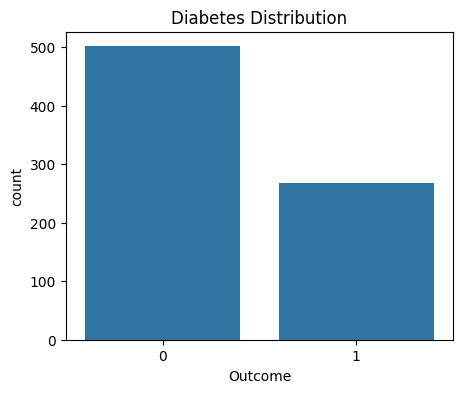

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x='Outcome', data=df)

plt.title("Diabetes Distribution")

plt.show()

Correlation Heatmap

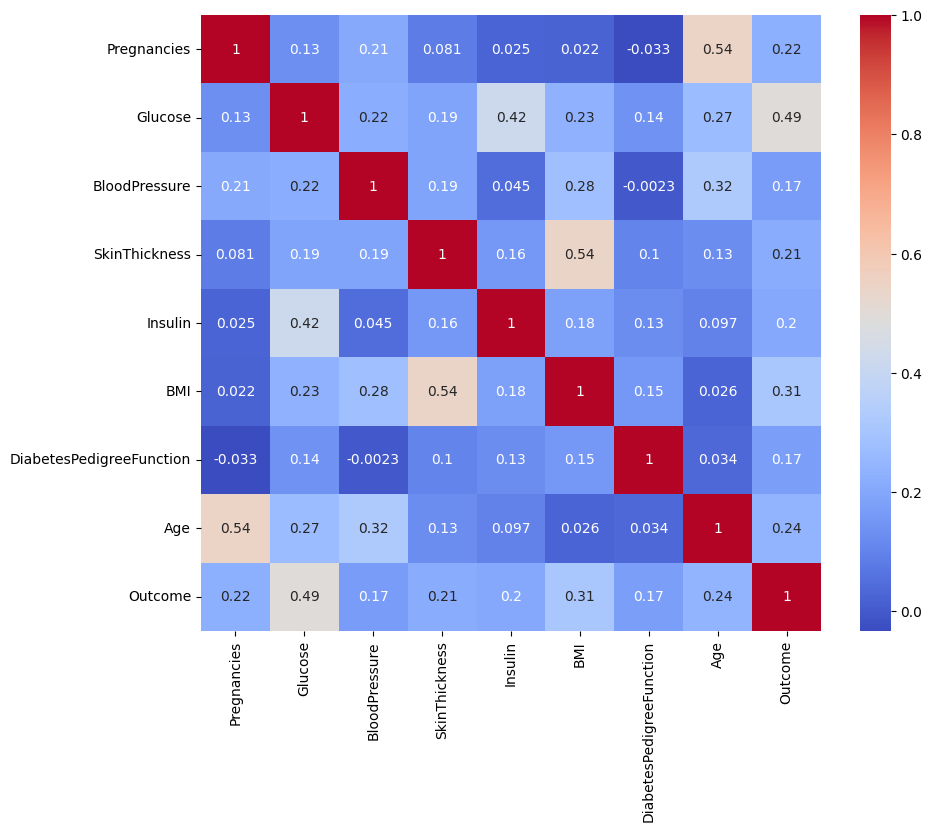

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

Histograms

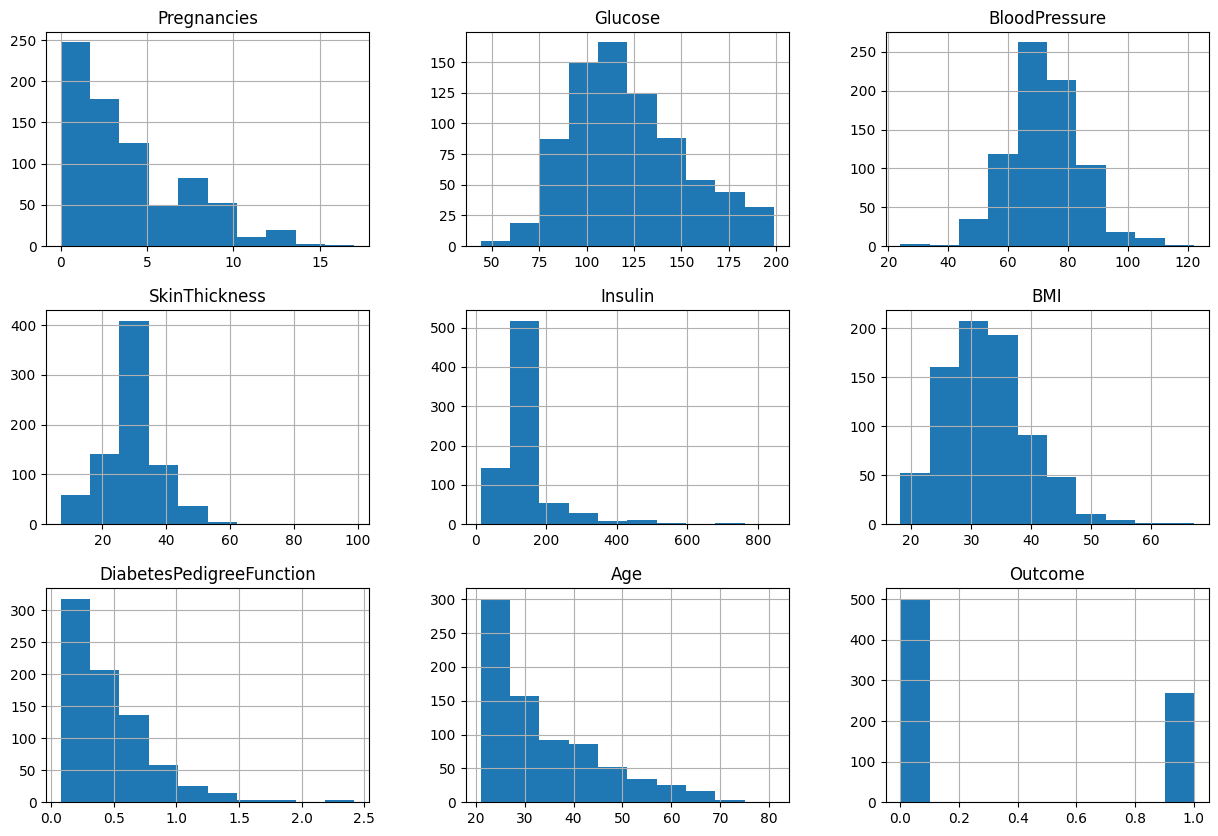

In [ ]:
df.hist(figsize=(15,10))

plt.show()

Boxplots

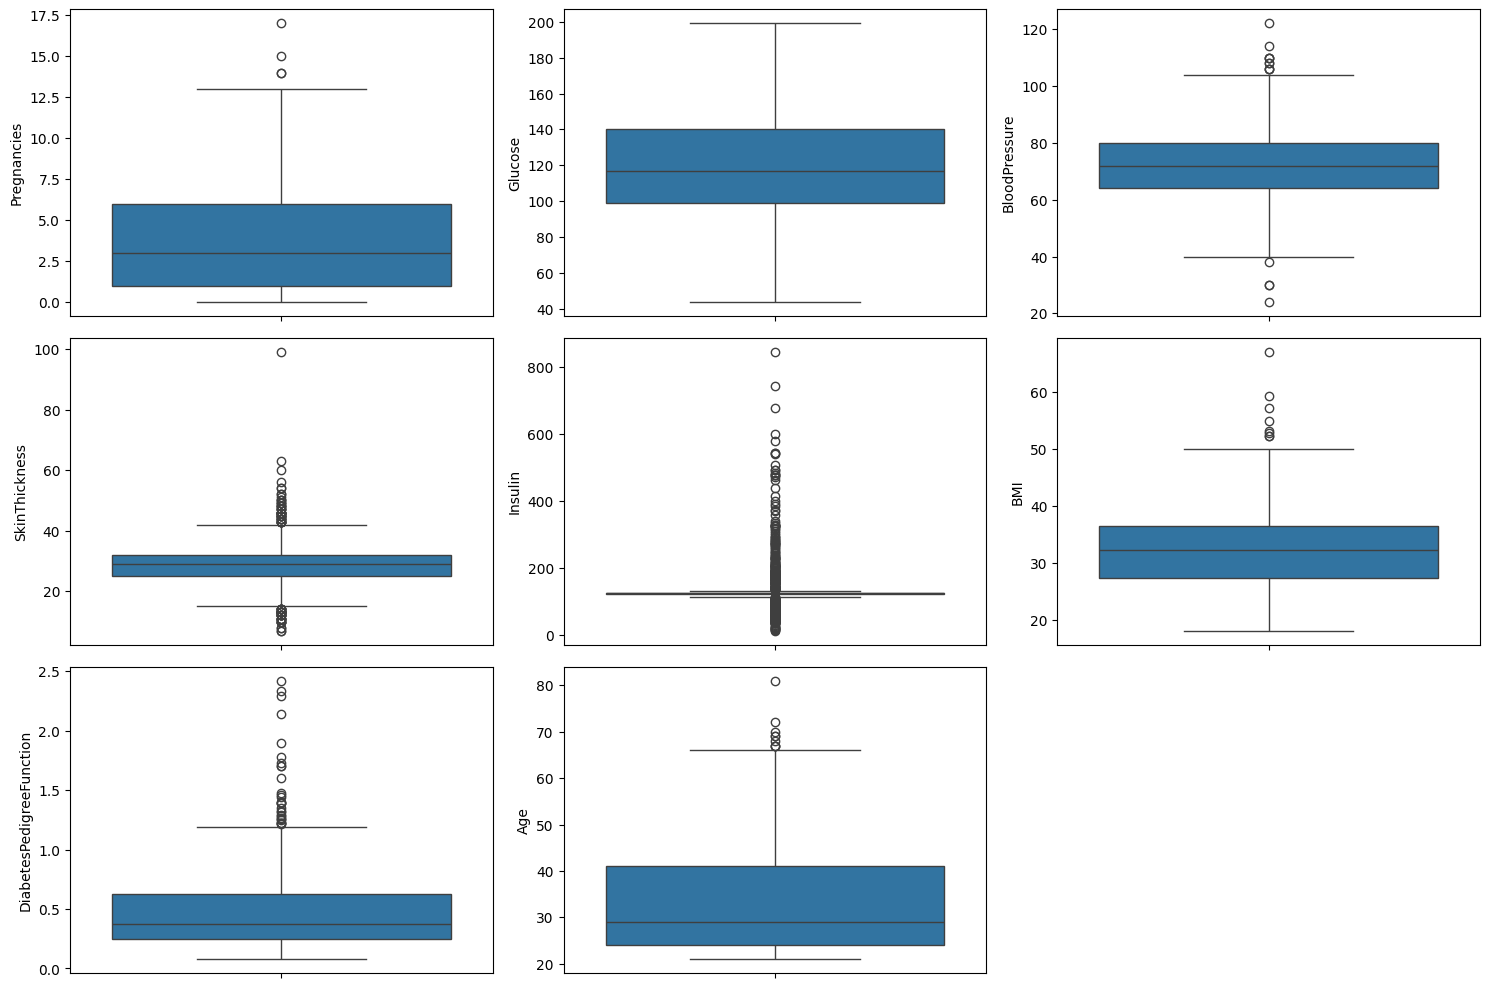

In [ ]:
plt.figure(figsize=(15,10))

for i,column in enumerate(df.columns[:-1]):

    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[column])

plt.tight_layout()

plt.show()

Step 8: Feature Selection

In [ ]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

Step 9: Feature Scaling (Very Important for KNN)

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Step 10: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

Step 11: Create KNN Model

Here, k = 5.

In [ ]:
model = KNeighborsClassifier(
    n_neighbors=5
)

model.fit(X_train, y_train)

KNeighborsClassifier()

Step 12: Predict Test Data

In [ ]:
y_pred = model.predict(X_test)

Step 14: Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[76 24]
 [16 38]]


Visualize

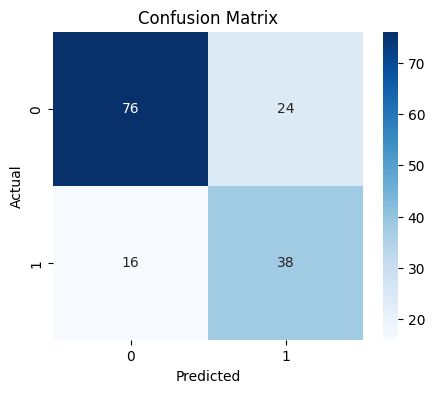

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Step 15: Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.76      0.79       100
           1       0.61      0.70      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



Step 16: Predict New Patient

In [ ]:
new_patient = [[
    2,
    150,
    80,
    30,
    120,
    28,
    0.50,
    35
]]

new_patient_scaled = scaler.transform(new_patient)

prediction = model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("Prediction : Diabetes")
else:
    print("Prediction : No Diabetes")

Prediction : No Diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Step 17: Predict Probability

In [ ]:
probability = model.predict_proba(new_patient_scaled)

print("Probability of No Diabetes :", probability[0][0])

print("Probability of Diabetes :", probability[0][1])

Probability of No Diabetes : 0.8
Probability of Diabetes : 0.2


Step 18: Finding the Best K Value

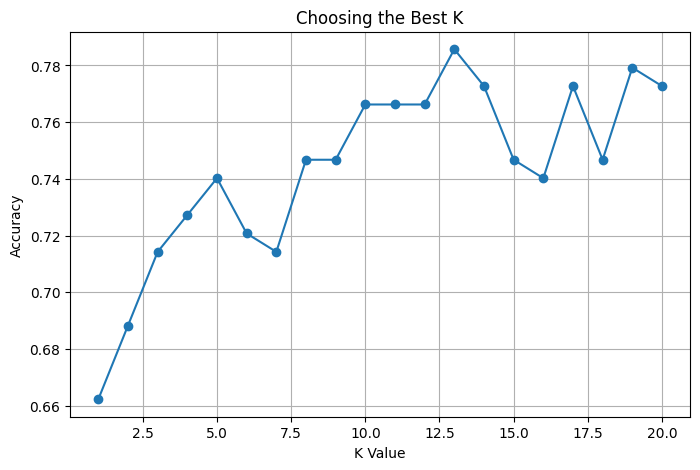

In [ ]:
accuracy_scores = []

for k in range(1,21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train,y_train)

    prediction = knn.predict(X_test)

    accuracy_scores.append(accuracy_score(y_test,prediction))

plt.figure(figsize=(8,5))

plt.plot(range(1,21),
         accuracy_scores,
         marker='o')

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("Choosing the Best K")

plt.grid(True)

plt.show()

Step 19: Compare Actual vs Predicted

In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(20)

,Actual,Predicted
0,0,1
1,0,0
2,0,0
3,1,1
4,0,1
5,0,1
6,0,0
7,0,0
8,0,1
9,0,0


Step 20: KNN Workflow

              Diabetes Dataset
                     │
                     ▼
              Load Dataset
                     │
                     ▼
             Understand Dataset
                     │
                     ▼
              Data Cleaning
                     │
                     ▼
          Replace Missing Values
                     │
                     ▼
         Exploratory Data Analysis
                     │
                     ▼
            Feature Selection
                     │
                     ▼
             Feature Scaling
                     │
                     ▼
            Train-Test Split
                     │
                     ▼
           K-Nearest Neighbors
                     │
                     ▼
             Model Training
                     │
                     ▼
                Prediction
                     │
                     ▼
           Accuracy Evaluation
                     │
                     ▼
           Confusion Matrix
                     │
                     ▼
        Classification Report
                     │
                     ▼
          Predict New Patient